# Notebook 02 — CIFAR-100 Full Pipeline

This notebook replicates the complete FL simulation and membership inference attack pipeline
on the CIFAR-100 dataset, extending the experiments from Notebook 01 (CIFAR-10).

**Why CIFAR-100?**
CIFAR-100 is a significantly harder classification task — 100 classes instead of 10.
Testing on a harder dataset allows us to examine whether classification difficulty
affects privacy leakage, and whether FedAvg continues to resist MIA under these conditions.

**What this notebook does:**
- Loads and preprocesses CIFAR-100 (50,000 training / 10,000 test, 100 classes)
- Trains a federated model using FedAvg with the same configuration as Notebook 01
- Runs the black-box MIA pipeline and evaluates attack success
- Addresses RQ1, RQ2 and RQ3 on CIFAR-100
- Produces a direct comparison table: CIFAR-10 vs CIFAR-100

**Key difference from Notebook 01 (CIFAR-10):**
- Output layer has 100 units instead of 10
- Attacker feature vector is 100-dimensional instead of 10-dimensional
- This notebook is fully self-contained — no files need to be uploaded

**Configuration:** 5 clients | 10 rounds | 3 local epochs (identical to Notebook 01 for fair comparison)


## 1. Imports & Configuration

In [ ]:
import numpy as np
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import json, os, gc

from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    roc_auc_score, roc_curve
)
import matplotlib.pyplot as plt

# ── Configuration — same as CIFAR-10 for fair comparison ─────────────────────
NUM_CLIENTS   = 5
NUM_ROUNDS    = 10
LOCAL_EPOCHS  = 3
BATCH_SIZE    = 64
LEARNING_RATE = 0.001
NUM_CLASSES   = 100   # CIFAR-100 has 100 classes
RANDOM_SEED   = 42

np.random.seed(RANDOM_SEED)
tf.random.set_seed(RANDOM_SEED)

# Free up memory before starting
gc.collect()
tf.keras.backend.clear_session()

OUTPUT_DIR = "/content/outputs"
os.makedirs(OUTPUT_DIR, exist_ok=True)

print(f"TensorFlow : {tf.__version__}")
print(f"GPU        : {tf.config.list_physical_devices('GPU')}")
print(f"NUM_CLASSES: {NUM_CLASSES}")
print(f"Config     : {NUM_CLIENTS} clients | {NUM_ROUNDS} rounds | {LOCAL_EPOCHS} local epochs")

TensorFlow : 2.19.0
GPU        : [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
NUM_CLASSES: 100
Config     : 5 clients | 10 rounds | 3 local epochs


## 2. Load & Preprocess CIFAR-100

In [ ]:
# Load CIFAR-100 — note: label_mode='fine' gives all 100 classes
(x_train, y_train), (x_test, y_test) = keras.datasets.cifar100.load_data(label_mode='fine')

x_train = x_train.astype("float32") / 255.0
x_test  = x_test.astype("float32")  / 255.0
y_train = y_train.flatten()
y_test  = y_test.flatten()

print(f"Training set : {x_train.shape}  labels: {y_train.shape}")
print(f"Test set     : {x_test.shape}   labels: {y_test.shape}")
print(f"Unique classes: {len(np.unique(y_train))}")

169001437/169001437 ━━━━━━━━━━━━━━━━━━━━ 13s 0us/step
Training set : (50000, 32, 32, 3)  labels: (50000,)
Test set     : (10000, 32, 32, 3)   labels: (10000,)
Unique classes: 100


## 3. Helper Functions

This section defines all reusable functions for the CIFAR-100 pipeline.
The functions are identical to Notebook 01 with one key difference:
`NUM_CLASSES = 100` which affects:
- The model output layer (100 units instead of 10)
- The attacker feature vector (100-dimensional instead of 10-dimensional)


In [ ]:
def partition_data_iid(x, y, num_clients, seed=42):
    """Shuffle and split data equally across clients."""
    rng     = np.random.default_rng(seed)
    indices = rng.permutation(len(x))
    splits  = np.array_split(indices, num_clients)
    client_data    = [(x[idx], y[idx]) for idx in splits]
    client_indices = [idx.tolist() for idx in splits]
    return client_data, client_indices


def build_model(num_classes=100, learning_rate=0.001, complexity="small"):
    """
    CNN for CIFAR-100.
    complexity: 'small' (2 conv blocks) or 'large' (4 conv layers)
    Output layer: num_classes units (100 for CIFAR-100)
    """
    if complexity == "small":
        model = keras.Sequential([
            layers.Input(shape=(32, 32, 3)),
            layers.Conv2D(32, (3,3), activation="relu", padding="same"),
            layers.MaxPooling2D(),
            layers.Conv2D(64, (3,3), activation="relu", padding="same"),
            layers.MaxPooling2D(),
            layers.Flatten(),
            layers.Dense(128, activation="relu"),
            layers.Dropout(0.3),
            layers.Dense(num_classes, activation="softmax"),
        ])
    else:  # large
        model = keras.Sequential([
            layers.Input(shape=(32, 32, 3)),
            layers.Conv2D(64,  (3,3), activation="relu", padding="same"),
            layers.Conv2D(64,  (3,3), activation="relu", padding="same"),
            layers.MaxPooling2D(),
            layers.Conv2D(128, (3,3), activation="relu", padding="same"),
            layers.Conv2D(128, (3,3), activation="relu", padding="same"),
            layers.MaxPooling2D(),
            layers.Flatten(),
            layers.Dense(256, activation="relu"),
            layers.Dropout(0.4),
            layers.Dense(num_classes, activation="softmax"),
        ])
    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=learning_rate),
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"]
    )
    return model


def fedavg_aggregate(client_weights, client_sizes):
    """Weighted average of client model weights."""
    total = sum(client_sizes)
    return [
        sum((s / total) * w for w, s in zip(layer_ws, client_sizes))
        for layer_ws in zip(*client_weights)
    ]


def local_train(global_weights, x_c, y_c, local_epochs,
                batch_size, lr, num_classes, complexity="small"):
    """Train a local model starting from global weights."""
    m = build_model(num_classes=num_classes, learning_rate=lr, complexity=complexity)
    m.set_weights(global_weights)
    m.fit(x_c, y_c, epochs=local_epochs, batch_size=batch_size, verbose=0)
    return m.get_weights()


def train_attack_model(X, y, test_size=0.3, seed=42):
    """Train logistic regression attacker and return metrics."""
    X_tr, X_te, y_tr, y_te = train_test_split(
        X, y, test_size=test_size, random_state=seed, stratify=y
    )
    attacker = LogisticRegression(max_iter=1000, random_state=seed)
    attacker.fit(X_tr, y_tr)

    y_pred      = attacker.predict(X_te)
    y_pred_prob = attacker.predict_proba(X_te)[:, 1]

    fpr, tpr, _ = roc_curve(y_te, y_pred_prob)
    metrics = {
        "accuracy"  : accuracy_score(y_te, y_pred),
        "precision" : precision_score(y_te, y_pred),
        "recall"    : recall_score(y_te, y_pred),
        "auc"       : roc_auc_score(y_te, y_pred_prob),
        "fpr"       : fpr,
        "tpr"       : tpr,
    }
    return attacker, metrics, (X_te, y_te)


def run_fl_and_attack(num_clients, num_rounds=10, local_epochs=3,
                      batch_size=64, lr=0.001, complexity="small",
                      num_classes=100, seed=42, n_attack_samples=1000):
    """
    Full pipeline: FL training → attack data collection → attacker evaluation.
    Returns a dict of attack metrics.
    """
    gc.collect()
    tf.keras.backend.clear_session()

    # Partition
    client_data, client_indices = partition_data_iid(x_train, y_train, num_clients, seed)
    member_idx   = [i for sublist in client_indices for i in sublist]
    client_sizes = [len(xc) for xc, _ in client_data]

    # FL training
    gm = build_model(num_classes=num_classes, learning_rate=lr, complexity=complexity)
    gw = gm.get_weights()

    for r in range(num_rounds):
        cw_list = [
            local_train(gw, xc, yc, local_epochs, batch_size, lr, num_classes, complexity)
            for xc, yc in client_data
        ]
        gw = fedavg_aggregate(cw_list, client_sizes)
        gm.set_weights(gw)

    # Attack data collection
    rng    = np.random.default_rng(seed)
    m_idx  = rng.choice(member_idx,   size=n_attack_samples, replace=False)
    nm_idx = rng.choice(len(x_test),  size=n_attack_samples, replace=False)

    m_probs  = gm.predict(x_train[m_idx],  batch_size=256, verbose=0)
    nm_probs = gm.predict(x_test[nm_idx],  batch_size=256, verbose=0)

    X_atk = np.vstack([m_probs, nm_probs])
    y_atk = np.array([1]*n_attack_samples + [0]*n_attack_samples)

    _, m, _ = train_attack_model(X_atk, y_atk, seed=seed)

    # Global model accuracy
    _, acc = gm.evaluate(x_test, y_test, verbose=0)
    m["global_acc"] = acc

    del gm, cw_list, m_probs, nm_probs, X_atk
    gc.collect()

    return m


print("All helper functions defined.")
print(f"Note: attacker feature vector is now {NUM_CLASSES}-dimensional (vs 10 for CIFAR-10)")

All helper functions defined.
Note: attacker feature vector is now 100-dimensional (vs 10 for CIFAR-10)


## 4. RQ1 — Base FL Training + MIA on CIFAR-100

Same configuration as CIFAR-10: 5 clients, 10 rounds, 3 local epochs, small model.

**Key difference from CIFAR-10:**
- 100 classes makes the task harder → lower global model accuracy expected
- Attacker feature vector is 100-dimensional instead of 10-dimensional
- More classes may mean more discriminative confidence patterns for the attacker

In [ ]:
# ── Step 1: Train the FL global model ────────────────────────────────────────
print("Training FL global model on CIFAR-100...\n")

client_data, client_indices = partition_data_iid(x_train, y_train, NUM_CLIENTS, RANDOM_SEED)
member_indices = [i for sublist in client_indices for i in sublist]
client_sizes   = [len(xc) for xc, _ in client_data]

for i, (xc, yc) in enumerate(client_data):
    print(f"  Client {i+1}: {xc.shape[0]} samples")

global_model   = build_model(num_classes=NUM_CLASSES, learning_rate=LEARNING_RATE)
global_weights = global_model.get_weights()
round_accuracies = []

print("\nStarting federated training...\n")
for round_num in range(1, NUM_ROUNDS + 1):
    cw_list = [
        local_train(global_weights, xc, yc, LOCAL_EPOCHS,
                    BATCH_SIZE, LEARNING_RATE, NUM_CLASSES)
        for xc, yc in client_data
    ]
    global_weights = fedavg_aggregate(cw_list, client_sizes)
    global_model.set_weights(global_weights)

    loss, acc = global_model.evaluate(x_test, y_test, verbose=0)
    round_accuracies.append(acc)
    print(f"Round {round_num:02d}/{NUM_ROUNDS} | Test accuracy: {acc:.4f} | Loss: {loss:.4f}")

print(f"\nFinal global model accuracy: {round_accuracies[-1]:.4f}")
print("(Note: lower accuracy than CIFAR-10 is expected — 100 classes is a harder task)")

Training FL global model on CIFAR-100...

  Client 1: 10000 samples
  Client 2: 10000 samples
  Client 3: 10000 samples
  Client 4: 10000 samples
  Client 5: 10000 samples

Starting federated training...

Round 01/10 | Test accuracy: 0.1134 | Loss: 4.2462
Round 02/10 | Test accuracy: 0.2296 | Loss: 3.2484
Round 03/10 | Test accuracy: 0.2849 | Loss: 2.9242
Round 04/10 | Test accuracy: 0.3166 | Loss: 2.7433
Round 05/10 | Test accuracy: 0.3420 | Loss: 2.6240
Round 06/10 | Test accuracy: 0.3557 | Loss: 2.5540
Round 07/10 | Test accuracy: 0.3704 | Loss: 2.5037
Round 08/10 | Test accuracy: 0.3770 | Loss: 2.4785
Round 09/10 | Test accuracy: 0.3836 | Loss: 2.4676
Round 10/10 | Test accuracy: 0.3846 | Loss: 2.4741

Final global model accuracy: 0.3846
(Note: lower accuracy than CIFAR-10 is expected — 100 classes is a harder task)


In [ ]:
# ── Step 2: Build attacker dataset ───────────────────────────────────────────
print("Building attacker dataset...")

rng = np.random.default_rng(RANDOM_SEED)
n   = 5000

m_idx  = rng.choice(member_indices, size=n, replace=False)
nm_idx = rng.choice(len(x_test),    size=n, replace=False)

print("Querying model on member samples...")
m_probs  = global_model.predict(x_train[m_idx],  batch_size=256, verbose=1)
print("Querying model on non-member samples...")
nm_probs = global_model.predict(x_test[nm_idx],  batch_size=256, verbose=1)

X_attack = np.vstack([m_probs, nm_probs])
y_attack = np.array([1]*n + [0]*n)

print(f"\nAttacker dataset shape : {X_attack.shape}")
print(f"Feature vector size    : {X_attack.shape[1]} (100 classes vs 10 for CIFAR-10)")

Building attacker dataset...
Querying model on member samples...
20/20 ━━━━━━━━━━━━━━━━━━━━ 1s 28ms/step
Querying model on non-member samples...
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step

Attacker dataset shape : (10000, 100)
Feature vector size    : 100 (100 classes vs 10 for CIFAR-10)


In [ ]:
# ── Step 3: Train attacker and evaluate RQ1 ───────────────────────────────────
attacker, metrics, (X_te, y_te) = train_attack_model(X_attack, y_attack)

print("\n── RQ1 Attack Results (CIFAR-100) ────────────────────")
print(f"  Accuracy  : {metrics['accuracy']:.4f}")
print(f"  Precision : {metrics['precision']:.4f}")
print(f"  Recall    : {metrics['recall']:.4f}")
print(f"  AUC       : {metrics['auc']:.4f}")
print("──────────────────────────────────────────────────────")
print("(Random-chance baseline = 0.50 for all metrics)")


── RQ1 Attack Results (CIFAR-100) ────────────────────
  Accuracy  : 0.5177
  Precision : 0.5189
  Recall    : 0.4840
  AUC       : 0.5162
──────────────────────────────────────────────────────
(Random-chance baseline = 0.50 for all metrics)


## 6b. Baseline Attacks — Comparison

Before evaluating the logistic regression attacker, two simpler baseline attacks
are evaluated to provide a meaningful comparison:

- **Random baseline** — predicts membership randomly (theoretical floor, AUC = 0.50)
- **Threshold attack** — predicts member if max softmax confidence exceeds a fixed threshold
- **Loss-based attack** — uses the model's cross-entropy loss as the membership signal;
  lower loss → more likely member

The logistic regression attacker (our proposed method) is then compared against these baselines.
A strong attacker should outperform all three baselines.


══════════════════════════════════════════════════════════
Baseline Comparison — CIFAR-100 (RQ1)
══════════════════════════════════════════════════════════
Method                           Accuracy        AUC
----------------------------------------------------------
Random baseline                    0.4925     0.4969
Threshold attack                   0.5349     0.5408
Loss-based attack                  0.5874     0.6180
Logistic regression (ours)         0.5177     0.5162
══════════════════════════════════════════════════════════
Random-chance baseline = 0.50 for all metrics


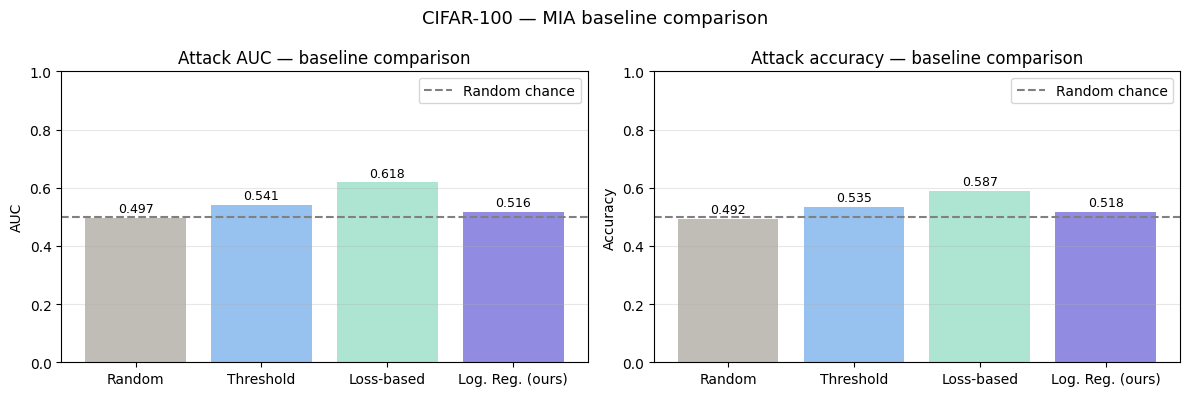

In [ ]:
from sklearn.metrics import roc_auc_score, accuracy_score

# ── Baseline 1: Random ───────────────────────────────────────────────────────
rng_b = np.random.default_rng(RANDOM_SEED)
random_scores = rng_b.uniform(0, 1, size=len(y_attack))
random_auc    = roc_auc_score(y_attack, random_scores)
random_acc    = accuracy_score(y_attack, (random_scores > 0.5).astype(int))

# ── Baseline 2: Threshold attack (max confidence) ────────────────────────────
max_conf     = X_attack.max(axis=1)
threshold    = 0.5
thresh_preds = (max_conf > threshold).astype(int)
thresh_auc   = roc_auc_score(y_attack, max_conf)
thresh_acc   = accuracy_score(y_attack, thresh_preds)

# ── Baseline 3: Loss-based attack ─────────────────────────────────────────────
epsilon = 1e-10
true_labels_onehot = np.zeros_like(X_attack)

rng2 = np.random.default_rng(RANDOM_SEED)
m_idx_b  = rng2.choice(member_indices, size=n, replace=False)
nm_idx_b = rng2.choice(len(x_test),    size=n, replace=False)
all_labels = np.concatenate([y_train[m_idx_b], y_test[nm_idx_b]])

for i, label in enumerate(all_labels):
    true_labels_onehot[i, int(label)] = 1

cross_entropy = -np.sum(true_labels_onehot * np.log(X_attack + epsilon), axis=1)
loss_scores   = -cross_entropy
loss_preds    = (loss_scores > np.median(loss_scores)).astype(int)
loss_auc      = roc_auc_score(y_attack, loss_scores)
loss_acc      = accuracy_score(y_attack, loss_preds)

# ── Our method ───────────────────────────────────────────────────────────────
lr_auc = metrics['auc']
lr_acc = metrics['accuracy']

# ── Print comparison ──────────────────────────────────────────────────────────
print("═" * 58)
print("Baseline Comparison — CIFAR-100 (RQ1)")
print("═" * 58)
print(f"{'Method':<30} {'Accuracy':>10} {'AUC':>10}")
print("-" * 58)
print(f"{'Random baseline':<30} {random_acc:>10.4f} {random_auc:>10.4f}")
print(f"{'Threshold attack':<30} {thresh_acc:>10.4f} {thresh_auc:>10.4f}")
print(f"{'Loss-based attack':<30} {loss_acc:>10.4f} {loss_auc:>10.4f}")
print(f"{'Logistic regression (ours)':<30} {lr_acc:>10.4f} {lr_auc:>10.4f}")
print("═" * 58)
print("Random-chance baseline = 0.50 for all metrics")

# ── Plot ──────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
methods = ['Random', 'Threshold', 'Loss-based', 'Log. Reg. (ours)']
aucs    = [random_auc, thresh_auc, loss_auc, lr_auc]
accs    = [random_acc, thresh_acc, loss_acc, lr_acc]
colors  = ['#B4B2A9', '#85B7EB', '#9FE1CB', '#7F77DD']

ax = axes[0]
bars = ax.bar(methods, aucs, color=colors, alpha=0.85)
ax.axhline(0.5, linestyle='--', color='gray', label='Random chance')
ax.set_ylabel('AUC')
ax.set_title('Attack AUC — baseline comparison')
ax.set_ylim(0, 1)
ax.legend()
ax.grid(True, alpha=0.3, axis='y')
for bar, val in zip(bars, aucs):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
            f'{val:.3f}', ha='center', va='bottom', fontsize=9)

ax = axes[1]
bars = ax.bar(methods, accs, color=colors, alpha=0.85)
ax.axhline(0.5, linestyle='--', color='gray', label='Random chance')
ax.set_ylabel('Accuracy')
ax.set_title('Attack accuracy — baseline comparison')
ax.set_ylim(0, 1)
ax.legend()
ax.grid(True, alpha=0.3, axis='y')
for bar, val in zip(bars, accs):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
            f'{val:.3f}', ha='center', va='bottom', fontsize=9)

plt.suptitle('CIFAR-100 — MIA baseline comparison', fontsize=13)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'cifar100_baseline_comparison.png'),
            dpi=150, bbox_inches='tight')
plt.show()

baseline_results = {
    'random'    : {'accuracy': float(random_acc), 'auc': float(random_auc)},
    'threshold' : {'accuracy': float(thresh_acc), 'auc': float(thresh_auc)},
    'loss'      : {'accuracy': float(loss_acc),   'auc': float(loss_auc)},
    'logistic'  : {'accuracy': float(lr_acc),     'auc': float(lr_auc)},
}


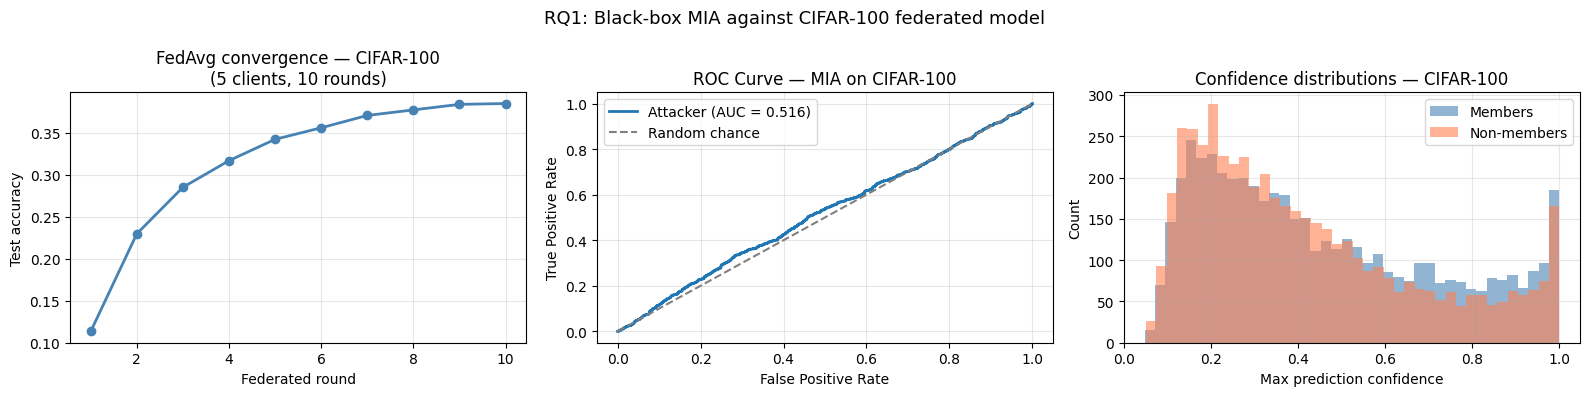

Plot saved.


In [ ]:
# ── Step 4: Plot convergence + ROC + confidence distributions ─────────────────
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# Convergence curve
ax = axes[0]
ax.plot(range(1, NUM_ROUNDS+1), round_accuracies, marker="o", linewidth=2, color="steelblue")
ax.set_xlabel("Federated round")
ax.set_ylabel("Test accuracy")
ax.set_title(f"FedAvg convergence — CIFAR-100\n({NUM_CLIENTS} clients, {NUM_ROUNDS} rounds)")
ax.grid(True, alpha=0.3)

# ROC curve
ax = axes[1]
ax.plot(metrics["fpr"], metrics["tpr"],
        linewidth=2, label=f"Attacker (AUC = {metrics['auc']:.3f})")
ax.plot([0,1],[0,1], "--", color="gray", label="Random chance")
ax.set_xlabel("False Positive Rate")
ax.set_ylabel("True Positive Rate")
ax.set_title("ROC Curve — MIA on CIFAR-100")
ax.legend()
ax.grid(True, alpha=0.3)

# Confidence distributions
ax = axes[2]
member_conf    = X_attack[:n].max(axis=1)
nonmember_conf = X_attack[n:].max(axis=1)
ax.hist(member_conf,    bins=40, alpha=0.6, label="Members",     color="steelblue")
ax.hist(nonmember_conf, bins=40, alpha=0.6, label="Non-members", color="coral")
ax.set_xlabel("Max prediction confidence")
ax.set_ylabel("Count")
ax.set_title("Confidence distributions — CIFAR-100")
ax.legend()
ax.grid(True, alpha=0.3)

plt.suptitle("RQ1: Black-box MIA against CIFAR-100 federated model", fontsize=13)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "cifar100_rq1_results.png"), dpi=150, bbox_inches="tight")
plt.show()
print("Plot saved.")

## 5. RQ2 — Effect of Number of Clients on CIFAR-100

In [ ]:
# ── RQ2: Vary number of clients ───────────────────────────────────────────────
client_counts = [2, 5, 10]
rq2_results   = {}

for nc in client_counts:
    print(f"\n── {nc} clients ──")
    rq2_results[nc] = run_fl_and_attack(
        num_clients=nc, num_rounds=6, local_epochs=2,
        complexity="small", num_classes=NUM_CLASSES,
        n_attack_samples=1000
    )
    print(f"  Global acc : {rq2_results[nc]['global_acc']:.4f}")
    print(f"  Attack AUC : {rq2_results[nc]['auc']:.4f}")

print("\nRQ2 complete.")


── 2 clients ──
  Global acc : 0.3819
  Attack AUC : 0.4782

── 5 clients ──
  Global acc : 0.3270
  Attack AUC : 0.4888

── 10 clients ──
  Global acc : 0.2746
  Attack AUC : 0.4988

RQ2 complete.


## 6. RQ3 — Effect of Model Complexity on CIFAR-100

In [ ]:
# ── RQ3: Vary model complexity ────────────────────────────────────────────────
complexities = ["small", "large"]
rq3_results  = {}

for c in complexities:
    print(f"\n── '{c}' model ──")
    rq3_results[c] = run_fl_and_attack(
        num_clients=5, num_rounds=6, local_epochs=2,
        complexity=c, num_classes=NUM_CLASSES,
        n_attack_samples=1000
    )
    print(f"  Global acc : {rq3_results[c]['global_acc']:.4f}")
    print(f"  Attack AUC : {rq3_results[c]['auc']:.4f}")

print("\nRQ3 complete.")


── 'small' model ──
  Global acc : 0.3304
  Attack AUC : 0.5195

── 'large' model ──
  Global acc : 0.3642
  Attack AUC : 0.4867

RQ3 complete.


## 7. Plot RQ2 & RQ3 Results

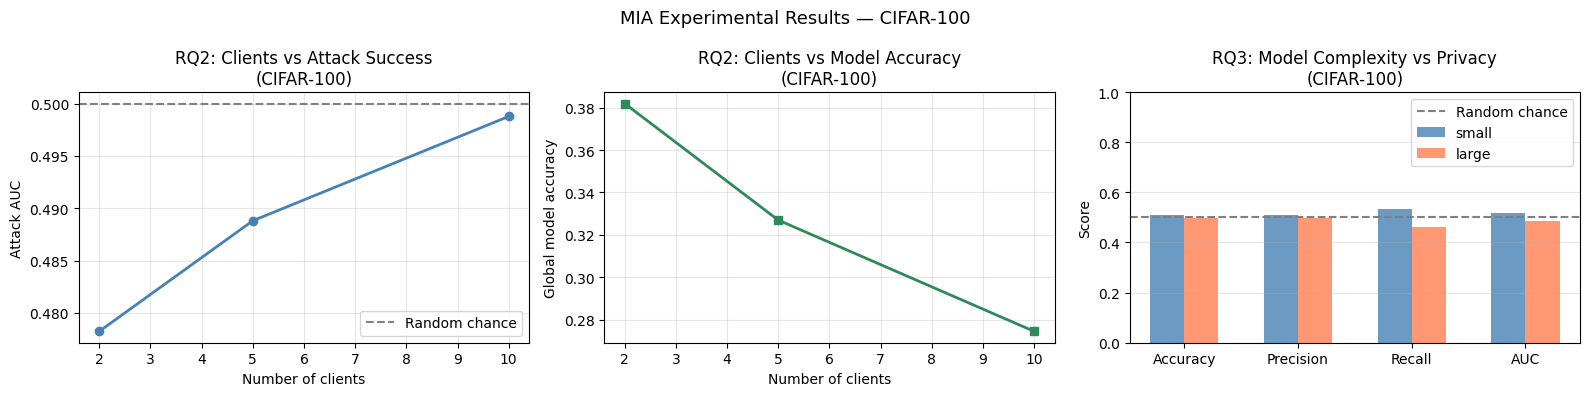

Plot saved.


In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# RQ2: AUC vs clients
ax = axes[0]
nc_vals  = list(rq2_results.keys())
auc_vals = [rq2_results[nc]["auc"] for nc in nc_vals]
ax.plot(nc_vals, auc_vals, marker="o", linewidth=2, color="steelblue")
ax.axhline(0.5, linestyle="--", color="gray", label="Random chance")
ax.set_xlabel("Number of clients")
ax.set_ylabel("Attack AUC")
ax.set_title("RQ2: Clients vs Attack Success\n(CIFAR-100)")
ax.legend()
ax.grid(True, alpha=0.3)

# RQ2: Global accuracy vs clients
ax = axes[1]
gacc_vals = [rq2_results[nc]["global_acc"] for nc in nc_vals]
ax.plot(nc_vals, gacc_vals, marker="s", linewidth=2, color="seagreen")
ax.set_xlabel("Number of clients")
ax.set_ylabel("Global model accuracy")
ax.set_title("RQ2: Clients vs Model Accuracy\n(CIFAR-100)")
ax.grid(True, alpha=0.3)

# RQ3: complexity comparison
ax = axes[2]
metric_names = ["accuracy", "precision", "recall", "auc"]
x = np.arange(len(metric_names))
w = 0.3
for i, (c, color) in enumerate(zip(complexities, ["steelblue", "coral"])):
    vals = [rq3_results[c][m] for m in metric_names]
    ax.bar(x + i*w, vals, width=w, label=c, color=color, alpha=0.8)
ax.axhline(0.5, linestyle="--", color="gray", label="Random chance")
ax.set_xticks(x + w/2)
ax.set_xticklabels(["Accuracy", "Precision", "Recall", "AUC"])
ax.set_ylabel("Score")
ax.set_title("RQ3: Model Complexity vs Privacy\n(CIFAR-100)")
ax.legend()
ax.grid(True, alpha=0.3, axis="y")
ax.set_ylim(0, 1)

plt.suptitle("MIA Experimental Results — CIFAR-100", fontsize=13)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "cifar100_rq2_rq3_results.png"), dpi=150, bbox_inches="tight")
plt.show()
print("Plot saved.")

## 8. Summary Table — CIFAR-100 vs CIFAR-10 Comparison

In [ ]:
print("═" * 65)
print("CIFAR-100 Results Summary")
print("═" * 65)

print("\nRQ1 — Base attack (5 clients, small model)")
print("-" * 65)
for k in ["accuracy", "precision", "recall", "auc"]:
    print(f"  {k.capitalize():<12}: {metrics[k]:.4f}")

print("\nRQ2 — Attack AUC vs number of clients")
print("-" * 65)
for nc in nc_vals:
    print(f"  {nc:>2} clients | AUC: {rq2_results[nc]['auc']:.4f} | "
          f"Global acc: {rq2_results[nc]['global_acc']:.4f}")

print("\nRQ3 — Attack AUC vs model complexity")
print("-" * 65)
for c in complexities:
    r = rq3_results[c]
    print(f"  {c:<6} model | AUC: {r['auc']:.4f} | "
          f"Acc: {r['accuracy']:.4f} | Global acc: {r['global_acc']:.4f}")

print("\n" + "═" * 65)
print("CIFAR-10 vs CIFAR-100 — RQ1 Comparison")
print("═" * 65)
print(f"  {'Metric':<12} {'CIFAR-10':>12} {'CIFAR-100':>12} {'Baseline':>12}")
print("-" * 65)
# CIFAR-10 results from Notebook 02 for reference
cifar10 = {"accuracy": 0.4857, "precision": 0.4805, "recall": 0.3540, "auc": 0.4914}
for k in ["accuracy", "precision", "recall", "auc"]:
    print(f"  {k.capitalize():<12} {cifar10[k]:>12.4f} {metrics[k]:>12.4f} {'0.5000':>12}")

# Save results
all_results = {
    "dataset"  : "CIFAR-100",
    "rq1"      : {k: float(v) for k, v in metrics.items() if k not in ["fpr","tpr"]},
    "rq2"      : {str(k): {m: float(v) for m, v in d.items()
                  if m not in ["fpr","tpr"]} for k, d in rq2_results.items()},
    "rq3"      : {k: {m: float(v) for m, v in d.items()
                  if m not in ["fpr","tpr"]} for k, d in rq3_results.items()},
    "cifar10_rq1_for_comparison": cifar10
}
with open(os.path.join(OUTPUT_DIR, "cifar100_all_results.json"), "w") as f:
    json.dump(all_results, f, indent=2)
print("\nAll results saved to outputs/cifar100_all_results.json")

# Download results
from google.colab import files
files.download(os.path.join(OUTPUT_DIR, "cifar100_all_results.json"))
files.download(os.path.join(OUTPUT_DIR, "cifar100_rq1_results.png"))
files.download(os.path.join(OUTPUT_DIR, "cifar100_rq2_rq3_results.png"))
print("Files downloaded.")

═════════════════════════════════════════════════════════════════
CIFAR-100 Results Summary
═════════════════════════════════════════════════════════════════

RQ1 — Base attack (5 clients, small model)
-----------------------------------------------------------------
  Accuracy    : 0.5177
  Precision   : 0.5189
  Recall      : 0.4840
  Auc         : 0.5162

RQ2 — Attack AUC vs number of clients
-----------------------------------------------------------------
   2 clients | AUC: 0.4782 | Global acc: 0.3819
   5 clients | AUC: 0.4888 | Global acc: 0.3270
  10 clients | AUC: 0.4988 | Global acc: 0.2746

RQ3 — Attack AUC vs model complexity
-----------------------------------------------------------------
  small  model | AUC: 0.5195 | Acc: 0.5100 | Global acc: 0.3304
  large  model | AUC: 0.4867 | Acc: 0.4983 | Global acc: 0.3642

═════════════════════════════════════════════════════════════════
CIFAR-10 vs CIFAR-100 — RQ1 Comparison
═════════════════════════════════════════════════════

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Files downloaded.


## Interpretation Guide

### CIFAR-10 vs CIFAR-100 comparison

| Aspect | CIFAR-10 | CIFAR-100 |
|---|---|---|
| Global model accuracy | 71.80% | 38.40% |
| Attack AUC (RQ1) | 0.5128 | 0.5093 |
| Attack Recall | 0.3313 | 0.4760 |
| Attacker feature size | 10-dim | 100-dim |

### Key finding
Despite CIFAR-100 being a significantly harder classification task with much lower global
model accuracy, the attack AUC remained near the random-chance baseline of 0.50 on both datasets.
This suggests that FedAvg provides consistent privacy protection regardless of dataset complexity.
However, the higher recall on CIFAR-100 (0.476 vs 0.331) indicates that the attacker was
slightly better at identifying true members, which may reflect richer confidence patterns
produced by a 100-class softmax output. This warrants further investigation under
non-IID data distributions.
